<a href="https://colab.research.google.com/github/Toussaintduk/MTF-Electricty-Acess-Nigeria-/blob/main/Copy_of_MTF_Electricity_ng_with_sns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import os
import zipfile


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Extract
drive_path = "/content/drive/MyDrive/energy data analaytics/nigeria Mtf"
zip_path = f"{drive_path}/raw-data_nigeria.zip"
extract_path = "/content/nigeria_data"
uploaded_path = "/content/nigeria_data/TO UPLOAD"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data

Files from the MTF North-West Nigeria survey (2017), all joined on `HH_ID`:

| File | One row = | What we take from it |
|---|---|---|
| `MTF_NG_HH_Identification.dta` | one household | `state_id`, `Urbanization` |
| `MTF_NG_HH_SEC_A1.dta` (roster) | one household member | sex of the household head |
| `MTF_NG_HH_SEC_C.dta` | one household | every electricity-source question, and `C182` = main source |
| `ng_weights.dta` | one household | survey weight `wt` |

`pandas` (`pd`) holds these as **DataFrames**; `numpy` (`np`) supplies `np.nan` for missing values. `load_sata_data` applies the Stata value labels, so responses read as text (`'Yes'`, `'National Grid Connection'`) rather than numeric codes. A repeated `HH_ID` in the roster is several members of one household, not several households — we reduce it to one value per household before merging.


In [ ]:
def load_sata_data(file_name):
    return pd.read_stata(os.path.join(uploaded_path, file_name))

In [ ]:
hh = load_sata_data('MTF_NG_HH_Identification.dta')
hh[['HH_ID', 'state_id', 'Urbanization']].head(2)


,HH_ID,state_id,Urbanization
0,1.000506e+12,Sokoto,Rural
1,1.000506e+12,Sokoto,Rural


## Sex of the household head

The MTF diagnostic reports results by locality and by **sex of the household head**; head sex is the one demographic we carry through here (Section 12). The Section A1 roster has one row per member — the head is the row with `A4 == 'Head'`, and `A3` gives their sex. We reduce it to one flag per household before merging.


In [ ]:
roster = load_sata_data('MTF_NG_HH_SEC_A1.dta')


In [ ]:
roster.head()

,HH_ID,individ,A3,A4,A5,A7,A8,A9,A11,A12,A14,A14_oths,A15,A16,A17,A18,A20,A19,interview__key
0,1.000506e+12,1,Male,Head,37,Yes,No,QUARANIC,Married,Never,Self-Employed Non Farm Business enterprise,,Wholesale and retail trade; repair of motor ve...,9.0,30.0,200000.0,0.0,No,88-06-47-05
1,1.000506e+12,2,Female,Wife/Spouse,30,Yes,No,QUARANIC,Married,A few times in a week,Self-Employed Non Farm Business enterprise,,Manufacturing,12.0,30.0,888.0,0.0,Yes,88-06-47-05
2,1.000506e+12,3,Female,Wife/Spouse,33,Yes,No,QUARANIC,Married,Everyday,Self-Employed Non Farm Business enterprise,,Manufacturing,12.0,30.0,20000.0,0.0,No,88-06-47-05
3,1.000506e+12,4,Female,Child/adopted child,12,Yes,Yes,P4,Never Married,Once a week,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,88-06-47-05
4,1.000506e+12,5,Female,Child/adopted child,2,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,88-06-47-05


In [ ]:
# Sex of the household head: the roster row where A4 == 'Head'.
head_sex = roster.loc[roster['A4'] == 'Head', ['HH_ID', 'A3']].rename(columns={'A3': 'head_sex'})
hh = hh.merge(head_sex, on='HH_ID', how='left')

hh['male_lead'] = (hh['head_sex'] == 'Male').astype(int)
hh['female_lead'] = (hh['head_sex'] == 'Female').astype(int)
hh = hh.drop(columns='head_sex')

hh[['HH_ID', 'state_id', 'Urbanization', 'male_lead', 'female_lead']].head()


,HH_ID,state_id,Urbanization,male_lead,female_lead
0,1.000506e+12,Sokoto,Rural,1,0
1,1.000506e+12,Sokoto,Rural,1,0
2,1.000506e+12,Sokoto,Rural,1,0
3,1.000506e+12,Sokoto,Rural,1,0
4,1.000506e+12,Sokoto,Rural,1,0


In [ ]:
sec_c = load_sata_data('MTF_NG_HH_SEC_C.dta')

# Main electricity source for each household. This one column drives every rule below.
sec_c['C182'].value_counts(dropna=False)


,count
C182,
Dry-cell battery,1998
National Grid Connection,1387
No electricity,203
Electric generator,47
"Other, specify",18
Solar Multi-Light Product,7
Solar Home System,4
Solar Lantern,2
Local Mini Grid connection,1


In [ ]:
weights = pd.read_stata(f'{drive_path}/ng_weights.dta')
weights[['HH_ID', 'wt']].head()


,HH_ID,wt
0,1.000506e+12,2608.320068
1,1.000506e+12,2608.320068
2,1.000506e+12,2608.320068
3,1.000506e+12,2608.320068
4,1.000506e+12,2608.320068


# Nigeria MTF: calculating electricity access tiers

Import the data → score six attribute tiers → take their minimum for the overall tier → apply survey weights → compare localities, states, and household-head sex.

Affordability is **not** assessed, so the overall tier is the minimum of **six** attributes, not the MTF's seven.

Two conventions run through every attribute:

- A default **Tier 5** means *no downgrade was established under our rule* — not proof of good service. A blank can be a skipped question or an unanswered one, and responses can contradict each other; we do not chase those contradictions here, and each section states how it treats missing information.
- A household that reports **no electricity** (`C182`) is given overall **Tier 0** directly, whatever the attribute columns say.

**Key structural difference from Rwanda:** Nigeria has no single "Main dataset.dta" with one row per household and every source question together. `MTF_NG_HH_SEC_C.dta` plays that role: one row per household (`HH_ID`), a question block per possible source (grid `C2`-`C42`, mini-grid `C43`-`C81`, generator `C83`-`C113`, rechargeable battery `C114`-`C133`, solar `C136`-`C189`), plus `C182` = the **main source**, which we take as authoritative. We build `elec`, one household-level table, by merging this section with `hh` (state, urbanization) and `ng_weights.dta` (weight `wt`).

`load_sata_data` applies the Stata value labels, so responses read as text (`'Yes'`, `'National Grid Connection'`).


In [ ]:
# One household-level analysis table: Section C + geography + survey weight.
elec = sec_c.merge(hh[['HH_ID', 'state_id', 'Urbanization']], on='HH_ID', how='left')
elec = elec.merge(weights[['HH_ID', 'wt']].drop_duplicates('HH_ID'), on='HH_ID', how='left')

assert not elec['HH_ID'].duplicated().any(), "elec must be one row per household"
elec[['HH_ID', 'C182', 'state_id', 'Urbanization', 'wt']].head()


,HH_ID,C182,state_id,Urbanization,wt
0,1.000506e+12,Dry-cell battery,Sokoto,Rural,2608.320068
1,1.000506e+12,Dry-cell battery,Sokoto,Rural,2608.320068
2,1.000506e+12,Dry-cell battery,Sokoto,Rural,2608.320068
3,1.000506e+12,Dry-cell battery,Sokoto,Rural,2608.320068
4,1.000506e+12,Dry-cell battery,Sokoto,Rural,2608.320068


## 2. Safety

Whether electricity caused a death or permanent bodily damage in the past 12 months.

| Main source (`C182`) | Incident question | Reason question |
|---|---|---|
| National Grid Connection | `C41` | `C42` |
| Local Mini Grid connection | `C81` | — |
| Electric generator | `C112` | `C113` |
| Rechargeable Battery | `C133` | — |
| Solar Home System / Solar Lantern / Solar Multi-Light Product | `C172` | — |

**Rule:** an explicit `'Yes'` on the incident question gives Tier 3; otherwise Tier 5. **Assumption:** an absent, unanswered, or non-`'Yes'` response does not establish a safety event — this can understate safety problems. `Dry-cell battery` (~54% of households) and `No electricity` have no matching safety question, so that large group defaults to Tier 5 here, exactly as the Rwanda notebook cautions.

Only **grid (`C42`) and generator (`C113`)** carry a follow-up asking the *reason* for the injury; mini-grid, battery and solar record the incident but not its cause. The reason does not enter the tier — we use it in a short finding below.

The dictionary pairs each main-source label with its incident question; the `for` loop repeats the same step for each pair. `.eq(...)` means "equals", `&` requires both conditions, and `.loc[rows, column]` writes only the matching rows of the one column.


In [ ]:
# Match each main source to its safety question.
safety_questions = {
    'National Grid Connection': 'C41',
    'Local Mini Grid connection': 'C81',
    'Electric generator': 'C112',
    'Rechargeable Battery': 'C133',
    'Solar Home System': 'C172',
    'Solar Lantern': 'C172',
    'Solar Multi-Light Product': 'C172',
}

# Start every household at Tier 5 under our no-explicit-event assumption.
elec['tier_safety'] = 5

# Repeat for each source and its question.
for source, question in safety_questions.items():
    elec.loc[
        elec['C182'].eq(source) & elec[question].eq('Yes'),
        'tier_safety'
    ] = 3


# elec['tier_safety'] = np.where(
# (elec['C182'] == source) & (elec[question] == 'Yes'),3,
# elec['tier_safety']
# )


In [ ]:
# Safety incidents behind Tier 3: households whose MAIN source caused a death or
# permanent injury in the last 12 months, and the reason they gave.
incident = elec['tier_safety'].eq(3)

print("Reported safety incidents by main source:")
print(elec.loc[incident, 'C182'].value_counts().to_string())

incident_weight_pct = 100 * elec.loc[incident, 'wt'].sum() / elec['wt'].sum()
print(f"\nTotal: {int(incident.sum())} households, "
      f"{incident_weight_pct:.2f}% of survey weight.\n")

# The reason follow-up exists only for grid (C42) and generator (C113).
for source, reason_col in [('National Grid Connection', 'C42'),
                          ('Electric generator', 'C113')]:
    rows = incident & elec['C182'].eq(source)
    if rows.any():
        print(f"{source} - reported reason ({reason_col}):")
        print(elec.loc[rows, reason_col].value_counts().to_string())
        print()


Reported safety incidents by main source:
C182
National Grid Connection      11
Electric generator             1
Local Mini Grid connection     0
Solar Lantern                  0
Solar Multi-Light Product      0
Solar Home System              0
Rechargeable Battery           0
Dry-cell battery               0
No electricity                 0
Other, specify                 0

Total: 12 households, 0.24% of survey weight.

National Grid Connection - reported reason (C42):
C42
Carelessness or error                               4
Lack of knowledge about the use of the appliance    3
Other, specify                                      3
Faulty wiring/connection                            1

Electric generator - reported reason (C113):
C113
Faulty wiring/connection    1



### Safety: the incidents behind Tier 3

Only **12 households** — about **0.2% of survey weight** — report a death or permanent injury from their main electricity source in the last 12 months: 11 on the grid, 1 on a generator, none on mini-grid, battery or solar. Safety therefore almost never sets a household's overall tier here (as in Rwanda).

Where a reason is recorded (`C42` grid, `C113` generator), **every case is installation- or behaviour-related** — faulty wiring / connection, carelessness or error, lack of knowledge about appliance use — not a fault inherent to the supply itself.

**Reading for the ministry:** the safety signal is small and points to **connection quality and consumer awareness** (certified wiring, safe-use guidance at hook-up) rather than to any technology being unsafe. On this evidence it is not a reason to prefer one source over another.


## 3. Formality

`C12` asks who receives payment for grid electricity; `C52` asks the same for mini-grid. **"No one" is `'No one/received for free'` in `C12` but `'No one'` in `C52`** — the same concept does not always carry the same code or label across a survey.

**Rule:** Tier 3 for these explicit no-payment responses; otherwise Tier 5. **Assumption:** missing answers, other payment arrangements, and sources without a matching question (generator, battery, solar, dry-cell) do not establish a lower tier. This is a teaching **proxy** for formality inferred from a payment question, not a legal determination about a connection.


In [ ]:
# Start at Tier 5 unless the specified payment response establishes Tier 3.
elec['tier_formality'] = 5

# Grid: 'No one/received for free' means no payment.
elec.loc[
    elec['C182'].eq('National Grid Connection') & elec['C12'].eq('No one/received for free'),
    'tier_formality'
] = 3

# Mini-grid: 'No one' means no payment.
elec.loc[
    elec['C182'].eq('Local Mini Grid connection') & elec['C52'].eq('No one'),
    'tier_formality'
] = 3


In [ ]:
elec['tier_formality'].value_counts()

,count
tier_formality,
5,3649
3,20


In [ ]:
elec['C52'].value_counts()

,count
C52,
Energy company (NEPA/PHCN),10
No one,5
Relative,1
Neighbor,1


In [ ]:
elec['C12'].value_counts()

,count
C12,
Energy company (NEPA/PHCN),1308
Neighbor,130
Community/village/municipality,83
Relative,49
Pre-paid meter card seller,48
Utility office,27
No one/received for free,25
Landlord,21
"Other, specify",8


In [ ]:
elec.loc[elec['C182'].eq('National Grid Connection') & elec['C12'].eq('No one/received for free')]['C12'].value_counts()

,count
C12,
No one/received for free,19
Energy company (NEPA/PHCN),0
Pre-paid meter card seller,0
Community/village/municipality,0
Neighbor,0
Relative,0
Landlord,0
Utility office,0
Post office,0


## 4. Quality

Whether voltage changes damaged appliances in the past 12 months.

| Main source | Question |
|---|---|
| National Grid Connection | `C_38` |
| Local Mini Grid connection | `C78` |
| Electric generator | `C109` |

**Rule:** `'Yes'` gives Tier 3; otherwise Tier 5. **Assumption:** missing, "Don't know", and unasked responses do not establish voltage damage — a household can land at Tier 5 without having *confirmed* good voltage quality. Nigeria has no pico-hydro sources, and battery / solar / dry-cell sources have no matching question, so those stay Tier 5 by default.


In [ ]:
# Match the sources with voltage-damage questions to their columns.
quality_questions = {
    'National Grid Connection': 'C_38',
    'Local Mini Grid connection': 'C78',
    'Electric generator': 'C109',
}

# Start at Tier 5 under our no-explicit-damage assumption.
elec['tier_quality'] = 5

# Repeat for each source and its question.
for source, question in quality_questions.items():
    elec.loc[
        elec['C182'].eq(source) & elec[question].eq('Yes'),
        'tier_quality'
    ] = 3


## 5. Reliability

`C_31b` (grid) and `C71b` (mini-grid) record outage **counts per week in a typical month** — already weekly, unlike Rwanda's per-day counts, which had to be multiplied by 7. Code **`888` means "Don't know"**, not 888 outages, so we replace it with missing before comparing.

| Weekly interruptions | Tier used here |
|---|---:|
| More than 14 | 3 |
| More than 3, up to 14 | 4 |
| At most 3, or unknown | 5 |

**What we leave out:** the full MTF reliability rule also uses outage *duration* to separate Tiers 4 and 5 at low frequency. We do not model duration, so we take the **highest tier not ruled out by the count alone**; at low counts this can **overstate** reliability. The published North-West Nigeria report measures Reliability for grid households only — we also cover the one mini-grid household, which barely moves the totals.

**Assumption:** missing counts, "Don't know" (`888`), and sources with no outage question (generator, battery, solar, dry-cell) stay Tier 5.

**Reading the code:** after `replace(888, np.nan)`, missing values fail the `> 3` and `> 14` comparisons, so they never trigger a downgrade. Order matters — a household with more than 14 interruptions is first set to Tier 4, then overwritten with Tier 3.


In [ ]:
# Match grid and mini-grid households to their typical-month weekly outage counts.
reliability_questions = {
    'National Grid Connection': 'C_31b',
    'Local Mini Grid connection': 'C71b',
}

# Start at the highest tier not yet ruled out.
elec['tier_reliability'] = 5

for source, question in reliability_questions.items():
    source_rows = elec['C182'].eq(source)

    # 888 = "Don't know" -> missing, so it is not read as 888 outages.
    weekly_outages = pd.to_numeric(elec[question], errors='coerce').replace(888, np.nan)

    # More than 3 interruptions rules out Tier 5.
    elec.loc[source_rows & weekly_outages.gt(3), 'tier_reliability'] = 4

    # More than 14 interruptions also rules out Tier 4.
    elec.loc[source_rows & weekly_outages.gt(14), 'tier_reliability'] = 3


## 6. Availability

**Hours electricity is available**, not hours the household uses it — using each source's typical-month ("b") daily and evening questions. `888` ("Don't know") is set to missing.

| Main source | Daily hours | Evening hours |
|---|---|---|
| National Grid Connection | `C_28b` | `C_29b` |
| Local Mini Grid connection | `C68b` | `C69b` |
| Electric generator | `C106b` | `C107b` |
| Rechargeable Battery | `C128` | `C129` |
| Solar Home System / Solar Lantern / Solar Multi-Light Product | `C169b` | `C170b` |

| Tier | Minimum daily hours | Minimum evening hours |
|---:|---:|---:|
| 1 | 4 | 1 |
| 2 | 4 | 2 |
| 3 | 8 | 3 |
| 4 | 16 | 4 |
| 5 | 23 | 4 |

**Rule:** start at Tier 5 and step down each time an observed answer fails a threshold; fewer than 4 daily hours **or** fewer than 1 evening hour gives Tier 0. `No electricity` gives Tier 0.

**Assumptions:** missing hours do not trigger a downgrade — if both daily and evening are missing, Tier 5 stands. `Dry-cell battery` has no availability question and is not downgraded here (its Tier 0 comes from Capacity, Section 7). Some evening answers exceed the daily answer; we keep both as reported and apply both thresholds without correcting either.

**Reading the code:** `pd.to_numeric(..., errors='coerce')` turns any "Don't know" label into missing; `|` is OR, so either failed requirement lowers the tier; the successive `.loc` assignments overwrite from the top down, leaving the lowest supported tier.


In [ ]:
# Map each main electricity source to its typical-month daily and evening availability questions.
availability_questions = {
    'National Grid Connection': ('C_28b', 'C_29b'),
    'Local Mini Grid connection': ('C68b', 'C69b'),
    'Electric generator': ('C106b', 'C107b'),
    'Rechargeable Battery': ('C128', 'C129'),
    'Solar Home System': ('C169b', 'C170b'),
    'Solar Lantern': ('C169b', 'C170b'),
    'Solar Multi-Light Product': ('C169b', 'C170b'),
}

In [ ]:
# Start at the highest tier not yet ruled out.
elec['tier_availability'] = 5

for source, (daily_question, evening_question) in availability_questions.items():
    source_rows = elec['C182'].eq(source)

    # Coerce any "Don't know" text to missing, and 888 ("Don't know") as well.
    daily = pd.to_numeric(elec[daily_question], errors='coerce').replace(888, np.nan)
    evening = pd.to_numeric(elec[evening_question], errors='coerce').replace(888, np.nan)

    # Fewer than 23 daily hours rules out Tier 5.
    elec.loc[source_rows & (daily < 23), 'tier_availability'] = 4

    # Failure of either Tier 4 requirement limits the tier to 3.
    elec.loc[source_rows & ((daily < 16) | (evening < 4)), 'tier_availability'] = 3

    # Failure of either Tier 3 requirement limits the tier to 2.
    elec.loc[source_rows & ((daily < 8) | (evening < 3)), 'tier_availability'] = 2

    # Failure of either Tier 2 requirement limits the tier to 1.
    elec.loc[source_rows & ((daily < 4) | (evening < 2)), 'tier_availability'] = 1

    # Failure of either Tier 1 requirement gives Tier 0.
    elec.loc[source_rows & ((daily < 4) | (evening < 1)), 'tier_availability'] = 0

# An explicit report of no electricity gives Tier 0.
elec.loc[elec['C182'].eq('No electricity'), 'tier_availability'] = 0


## 7. Capacity

**Data limitation:** Rwanda's capacity tier used Section L, which links each owned appliance to the energy source powering it (`Lc`). Nigeria's equivalent, `MTF_NG_HH_SEC_N_ELEC_ASSET.dta`, records appliance ownership counts (`own_asset`, `N1A_N31A`, `N1B_N31B`) but **has no source column**, so we cannot attribute an appliance to a specific main source the way Rwanda does. We use a simplified proxy based only on `C182` and the solar device-count questions, and leave the rest missing rather than guessing.

**Rule:**

| Main source (`C182`) | Capacity tier | Basis |
|---|---|---|
| National Grid Connection | 5 | Report convention: grid is auto-assigned Tier 5 for Capacity |
| Solar Home System (`C139` > 0) | 2 | Teaching minimum, matching Rwanda |
| Solar Lantern / Solar Multi-Light Product (`C137`/`C138` > 0) | 1 | Teaching minimum, matching Rwanda |
| No electricity | 0 | No source |
| **Dry-cell battery** | **0** | See below |
| Mini-grid, generator, rechargeable battery, Other, missing | *missing* | No basis to assign a capacity tier |

The solar minimums are **household teaching proxies** — demonstrated service, not a measured wattage or a sum of appliance ratings — following the Rwanda exercise; owning no high-power appliance is not proof the system could not power one. Where we have no basis at all (last row), we keep the Rwanda rule: **leave capacity missing, never default it to Tier 5.**

**Dry-cell battery → Tier 0.** Dry-cell battery is the single most common `C182` response (1,998 households, ~54%). It is **not** a source that can reach Tier 1: the MTF defines Tier 0 as a primary source with peak capacity below 3 W, and the North-West Nigeria diagnostic report (Box 1) describes Tier 0 households as those who *"cope by using candles, kerosene lamps, or devices powered by dry-cell batteries (flashlight or radio)."* Leaving these households unresolved (what the mechanical proxy does) is what strands ~60% of the sample without an overall tier; defaulting them to Tier 5 would be far worse. Assigning Tier 0 is the substantive reading and matches the published report. It mirrors the no-electricity handling and the Rwanda notebook's `C182 = 8 -> Tier 0` exception.

**Still left missing:** mini-grid (1), generator (47), rechargeable battery (1), and Other / missing main source (19) — 68 households in all. These are genuine electricity sources or unknowns with no capacity information, so their overall tier stays `NaN` and is reported separately, not forced to any tier.


In [ ]:
# Start with missing capacity tiers; fill them only using the agreed rules.
elec['tier_capacity'] = np.nan

solar_home_system = pd.to_numeric(elec['C139'], errors='coerce')
solar_lantern = pd.to_numeric(elec['C137'], errors='coerce')
solar_lighting = pd.to_numeric(elec['C138'], errors='coerce')

solar_rows = elec['C182'].isin(['Solar Home System', 'Solar Lantern', 'Solar Multi-Light Product'])

# Teaching minimums, matching Rwanda: Solar Home System = 2, other solar devices = 1.
elec.loc[solar_rows & (solar_home_system > 0), 'tier_capacity'] = 2
elec.loc[solar_rows & (solar_home_system.fillna(0) == 0) & ((solar_lantern > 0) | (solar_lighting > 0)), 'tier_capacity'] = 1

# Assign Tier 5 to grid households and Tier 0 to households with no electricity.
elec.loc[elec['C182'].eq('National Grid Connection'), 'tier_capacity'] = 5
elec.loc[elec['C182'].eq('No electricity'), 'tier_capacity'] = 0

# Dry-cell battery is a Tier 0 coping strategy under the MTF (peak capacity < 3 W;
# see the North-West Nigeria diagnostic report, Box 1), not a Tier 1+ source.
elec.loc[elec['C182'].eq('Dry-cell battery'), 'tier_capacity'] = 0


## 8. Overall tier

The household's overall tier is its **lowest** attribute tier: `elec[tier_columns].min(axis=1, skipna=False)`. `axis=1` works across the six columns within each household's row; `skipna=False` means a missing attribute produces a missing overall tier instead of being ignored (pandas would otherwise drop it and take the min of the rest, "Missing Overall Tiers").

Two explicit overrides sit on top of the minimum, both resolving to Tier 0:

- **No electricity** (`C182 = 'No electricity'`) — no source.
- **Dry-cell battery** — a Tier 0 coping strategy, not a Tier 1+ source (Section 7).

After these overrides, an overall tier is missing only when a genuine electricity source (generator, mini-grid, rechargeable battery) or an unknown main source has no usable capacity information. Those **68 households (~2.1% of survey weight)** stay `NaN` and are reported as *Unresolved* in every table below. We do **not** fill them with Tier 5: "no downgrade established under our rule" is not evidence of good service, and defaulting a large unresolved group upward would overstate access. Section 14 tests how much this choice matters.


In [ ]:
# List the six attribute-tier columns used in the overall calculation.
tier_columns = [
    'tier_capacity',
    'tier_availability',
    'tier_reliability',
    'tier_quality',
    'tier_formality',
    'tier_safety',
]

# Defragment after the many per-attribute column inserts above.
elec = elec.copy()

# Take the lowest tier in each row; retain missing if any attribute is missing.
elec['tier_overall'] = elec[tier_columns].min(axis=1, skipna=False)

# Explicit Tier 0 overrides: no source, and dry-cell battery (a Tier 0 coping strategy).
elec.loc[elec['C182'].eq('No electricity'), 'tier_overall'] = 0
elec.loc[elec['C182'].eq('Dry-cell battery'), 'tier_overall'] = 0

household_tiers = elec[['HH_ID', 'C182'] + tier_columns + ['tier_overall']].copy()

# How each main source maps to the overall tier (unweighted household counts).
# Label as strings first so the crosstab never has to sort str against float.
overall_label = elec['tier_overall'].map(
    lambda t: 'Unresolved' if pd.isna(t) else f'Tier {int(t)}'
)
pd.crosstab(elec['C182'], overall_label)


tier_overall,Tier 0,Tier 1,Tier 2,Tier 3,Tier 4,Tier 5,Unresolved
C182,,,,,,,
National Grid Connection,69,97,376,664,146,35,0
Local Mini Grid connection,0,0,0,0,0,0,1
Electric generator,0,0,0,0,0,0,47
Solar Lantern,0,1,1,0,0,0,0
Solar Multi-Light Product,0,7,0,0,0,0,0
Solar Home System,0,0,4,0,0,0,0
Rechargeable Battery,0,0,0,0,0,0,1
Dry-cell battery,1998,0,0,0,0,0,0
No electricity,203,0,0,0,0,0,0


## 9. Apply survey weights and report the national distribution

The sample is not a proportional miniature of North-West Nigeria: households had different probabilities of selection under the survey design, and survey weights undo that. The base idea is **weight = 1 / probability of selection**; we use the supplied `wt` (`ng_weights.dta`, already merged into `elec`), not weights recomputed from the sample counts. A weight changes how much a household **contributes to a distribution** — it never changes that household's tier. These are **household** percentages, not percentages of people.

**Reporting format**: show each overall tier with its **unweighted household count** beside its **weighted share**, keep *Unresolved* as its own row (`dropna=False`, so it stays in the denominator and is never folded into Tier 0), and state the unresolved count and weight share below the table. For each tier, weighted % = 100 × (sum of weights in that tier) / (sum of all household weights). This step corrects for sample representation only — not for missing responses or the tier-rule assumptions above.


In [ ]:
# Weighted share per overall tier; dropna=False keeps Unresolved in the denominator.
tier_weights = elec.groupby('tier_overall', dropna=False)['wt'].sum()
weighted_distribution = 100 * tier_weights / tier_weights.sum()

# National Tier Distribution table: unweighted count beside weighted %.
tier_counts = elec['tier_overall'].value_counts(dropna=False)
total_weight = elec['wt'].sum()

rows = []
for tier in sorted(t for t in tier_counts.index if pd.notna(t)):
    in_tier = elec['tier_overall'].eq(tier)
    rows.append((f'Tier {int(tier)}', int(in_tier.sum()),
                 round(100 * elec.loc[in_tier, 'wt'].sum() / total_weight, 2)))

unresolved = elec['tier_overall'].isna()
rows.append(('Unresolved', int(unresolved.sum()),
             round(100 * elec.loc[unresolved, 'wt'].sum() / total_weight, 2)))

national_distribution = pd.DataFrame(
    rows, columns=['overall_tier', 'households', 'weighted_pct']
).set_index('overall_tier')

print(f"Unresolved: {int(unresolved.sum())} households; "
      f"{100 * elec.loc[unresolved, 'wt'].sum() / total_weight:.2f}% of total survey weight.")
print("2017 MTF North-West Nigeria survey; six-attribute classroom reconstruction "
      "(Affordability not assessed).")

national_distribution


Unresolved: 68 households; 2.11% of total survey weight.
2017 MTF North-West Nigeria survey; six-attribute classroom reconstruction (Affordability not assessed).


,households,weighted_pct
overall_tier,,
Tier 0,2270,65.360001
Tier 1,105,2.430000
Tier 2,381,10.640000
Tier 3,664,16.059999
Tier 4,146,2.710000
Tier 5,35,0.690000
Unresolved,68,2.110000


## 9a. Comparison with the published diagnostic report

Lecture 4 ("Comparison with the Report", "Why don't they match exactly?") sets the expectation: check a classroom reconstruction against the official figures and explain the gaps rather than smooth them over.

The *Energy Access Diagnostic Report &mdash; North-West Nigeria* (World Bank / ESMAP, 2018) reports, for electricity access:

- **Tier 0: 60.7%** of households; **Tier 1 or above: ~40%**; **almost none in Tier 5**.
- By locality: about **three in four rural** households in Tier 0; about **one in four urban** households in Tier 0.
- 46.3% of households connected to the grid; grid households mostly in Tiers 2&ndash;3.

The report uses all seven attributes (including Affordability), measures Reliability for grid households only, and builds Capacity from the full appliance-to-source linkage. Our six-attribute reconstruction cannot.


In [ ]:
# Our weighted headline vs. the published report.
resolved = [tier for tier in weighted_distribution.index if pd.notna(tier)]
our_tier0 = float(weighted_distribution.get(0.0, 0.0))
our_tier1_plus = float(weighted_distribution[[tier for tier in resolved if tier >= 1]].sum())
our_tier5 = float(weighted_distribution.get(5.0, 0.0))

comparison = pd.DataFrame(
    {
        'our_weighted_pct': [round(our_tier0, 1), round(our_tier1_plus, 1), round(our_tier5, 1)],
        'report_pct': [60.7, 40.0, 0.0],
    },
    index=['Tier 0', 'Tier 1 or above', 'Tier 5'],
)
comparison


,our_weighted_pct,report_pct
Tier 0,65.4,60.7
Tier 1 or above,32.5,40.0
Tier 5,0.7,0.0


Why the numbers differ:
- Affordability is not assessed here (6 attributes vs the report's 7); it can only lower tiers, so our Tier 3-5 shares are, if anything, high.
- Capacity for mini-grid / generator / rechargeable battery is unresolved (no appliance-to-source link in the Nigeria asset file), so ~2% of weight sits in 'Unresolved' rather than a tier.
- Reliability here also covers the single mini-grid household; the report restricts Reliability to the grid.
- Missing-response defaults (Tier 5 = 'no downgrade established') can lift attribute tiers where the report has more information.
- Treating dry-cell battery as Tier 0 is the main lever; it aligns our Tier 0 share with the report's 60.7%.

## 9b. National electricity tiers: synthesis

*Format. The observed result is kept separate from its interpretation.*

| | |
|---|---|
| **Finding** | About two-thirds of households (~65% weighted) are in Tier 0. Roughly one-third reach Tier 1 or above, and the Tier 4&ndash;5 share is about 3%. ~2% of survey weight is unresolved. |
| **Interpretation** | The binding constraint for most households is having no Tier 1+ source at all &mdash; dry-cell batteries and "no electricity" dominate. This is an *extensive-margin* access gap, not a service-quality gap. |
| **Policy trade-off** | Spend on giving Tier 0 households a first Tier 1+ source (grid connection or off-grid solar), or on lifting the ~33% already connected out of Tiers 2&ndash;3. The evidence points to the former as the larger gap. |
| **Conditional direction** | Grid extension where infrastructure already passes the household (the report notes grid infrastructure in 67.9% of EAs but only 46.3% of households connected) and connection cost is the barrier; off-grid solar where the grid is far or uneconomic. |
| **Evidence needed** | Connection cost vs. willingness to pay, distance to existing grid, off-grid product cost and capacity, and appliance demand &mdash; none of which this notebook contains. |
| **Source data** | 2017 MTF North-West Nigeria survey; six-attribute classroom reconstruction. Compare with the diagnostic report, Executive Summary and national-tier figure. |


## 10. Compare tier distributions by locality and by state

The diagnostic report presents the tier distribution three ways: **national**, **by locality (urban / rural)**, and **by sex of household head**. Locality is the report's primary disaggregation and the one we can check against it, so we do it first; by-state is an extra within-survey view.

We want the distribution **within each group**, not each group's share of the national total: group by (group, tier), sum the weights, and divide each row by that group's **own** total weight, so every row sums to ~100% (small gaps are rounding), *Unresolved* column included. `unstack` moves tiers into columns; `fill_value=0` fills group–tier cells with no households (it does not reassign missing households to a tier); `.div(totals, axis=0)` divides each row by its matching group total. Differences between groups are **descriptive, not causal**.


In [ ]:
# Weighted tier distribution within each locality (urban / rural).
elec['Urbanization'] = elec['Urbanization'].astype('string')

locality_weights = elec.groupby(['Urbanization', 'tier_overall'], dropna=False)['wt'].sum()
locality_weights = locality_weights.unstack(fill_value=0)
locality_distribution = 100 * locality_weights.div(locality_weights.sum(axis=1), axis=0)
locality_distribution = locality_distribution.loc[locality_distribution.index.notna()]

# Label tier columns, Unresolved included, so the table reads like the report's.
locality_distribution.columns = [
    'Unresolved' if pd.isna(tier) else f'Tier {int(tier)}'
    for tier in locality_distribution.columns
]
locality_distribution.round(2)


,Tier 0,Tier 1,Tier 2,Tier 3,Tier 4,Tier 5,Unresolved
Urbanization,,,,,,,
Rural,76.720001,0.97,7.3,10.71,1.83,0.50,1.96
Urban,33.889999,6.47,19.9,30.85,5.13,1.22,2.54


In [ ]:
# Add weights for each combination of state and overall tier.
region_weights = elec.groupby(['state_id', 'tier_overall'], dropna=False)['wt'].sum()

# Arrange states as rows and tiers as columns; absent combinations get zero.
region_weights = region_weights.unstack(fill_value=0)

# Add across the tier columns to get each state's total weight.
region_totals = region_weights.sum(axis=1)

# Divide each state's tier weights by its own total and multiply by 100.
region_distribution = 100 * region_weights.div(region_totals, axis=0)

region_distribution.round(2)


/tmp/ipykernel_4492/3190933792.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_weights = elec.groupby(['state_id', 'tier_overall'], dropna=False)['wt'].sum()


tier_overall,NaN,0.0,1.0,2.0,3.0,4.0,5.0
state_id,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Jigawa,0.16,93.250000,0.71,1.57,4.250000,0.06,0.01
Kaduna,4.23,40.500000,3.52,15.74,30.680000,5.10,0.24
Kano,3.44,57.700001,4.17,14.75,16.629999,2.55,0.76
Katsina,0.43,65.629997,1.64,12.97,15.570000,2.59,1.16
Kebbi,1.84,55.220001,2.19,8.44,26.059999,4.59,1.66
Sokoto,1.72,91.949997,0.00,2.56,2.930000,0.67,0.18
Zamfara,0.04,78.449997,1.52,6.53,9.740000,2.81,0.90


## 11. Visualizing tier distributions

Decision-facing views: the national tier distribution (Tier 0 first, *Unresolved* last), and Tier 1+ / Tier 0 access broken out by locality, by sampled state, and by sex of household head. Every figure carries a source caption; group differences are descriptive, not causal.


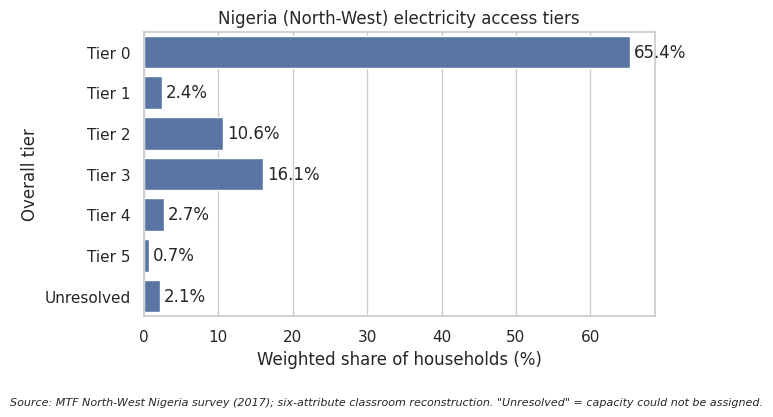

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)

SOURCE_NOTE = ('Source: MTF North-West Nigeria survey (2017); six-attribute classroom '
               'reconstruction. "Unresolved" = capacity could not be assigned.')

# Weighted national tier distribution: Tier 0 first, Unresolved last (Lecture 5 order).
fig, ax = plt.subplots(figsize=(7, 4.2))
national_plot_data = weighted_distribution.copy()
national_plot_data.index = [
    'Unresolved' if pd.isna(tier) else f'Tier {int(tier)}'
    for tier in national_plot_data.index
]
national_plot_data = national_plot_data.reindex(
    ['Tier 0', 'Tier 1', 'Tier 2', 'Tier 3', 'Tier 4', 'Tier 5', 'Unresolved']
)
sns.barplot(
    x=national_plot_data.values,
    y=national_plot_data.index,
    ax=ax,
    color=sns.color_palette('deep')[0],
    orient='h'
)

ax.set_xlabel('Weighted share of households (%)')
ax.set_ylabel('Overall tier')
ax.set_title('Nigeria (North-West) electricity access tiers')
for index, value in enumerate(national_plot_data):
    ax.text(value + 0.5, index, f'{value:.1f}%', va='center')

plt.tight_layout(rect=(0, 0.06, 1, 1))
fig.text(0.01, 0.015, SOURCE_NOTE, fontsize=8, style='italic')
plt.show()


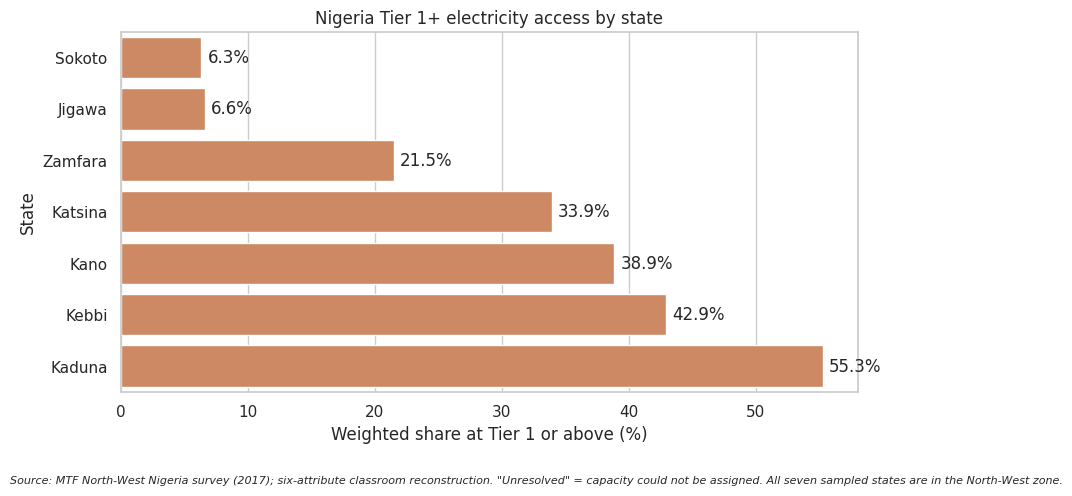

In [ ]:
# Weighted Tier 1+ access within each sampled state.
resolved_tiers = [column for column in region_distribution.columns if pd.notna(column)]
tier_one_plus = [tier for tier in resolved_tiers if tier >= 1]
state_tier_one_plus = region_distribution.loc[region_distribution.index.notna(), tier_one_plus].sum(axis=1).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x=state_tier_one_plus.values,
    y=state_tier_one_plus.index,
    ax=ax,
    color=sns.color_palette('deep')[1],
    order=state_tier_one_plus.index.tolist(),
    orient='h'
)

ax.set_xlabel('Weighted share at Tier 1 or above (%)')
ax.set_ylabel('State')
ax.set_title('Nigeria Tier 1+ electricity access by state')
for index, value in enumerate(state_tier_one_plus):
    ax.text(value + 0.5, index, f'{value:.1f}%', va='center')

plt.tight_layout(rect=(0, 0.06, 1, 1))
fig.text(0.01, 0.015, SOURCE_NOTE + ' All seven sampled states are in the North-West zone.',
         fontsize=8, style='italic')
plt.show()


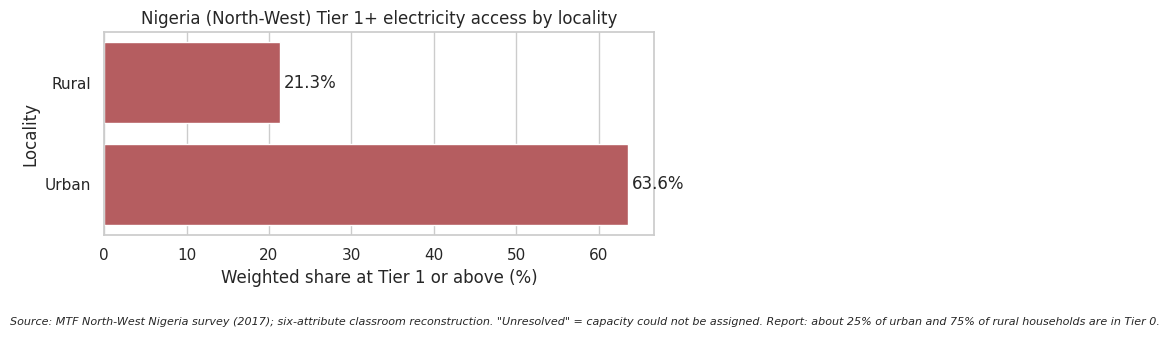

In [ ]:
# Weighted Tier 1+ access by locality, to compare directly with the report.
locality_resolved_cols = [
    column for column in locality_distribution.columns
    if column.startswith('Tier ') and column != 'Tier 0'
]
locality_tier_one_plus = locality_distribution[locality_resolved_cols].sum(axis=1).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.4))
sns.barplot(
    x=locality_tier_one_plus.values,
    y=locality_tier_one_plus.index,
    ax=ax,
    color=sns.color_palette('deep')[3],
    order=locality_tier_one_plus.index.tolist(),
    orient='h'
)

ax.set_xlabel('Weighted share at Tier 1 or above (%)')
ax.set_ylabel('Locality')
ax.set_title('Nigeria (North-West) Tier 1+ electricity access by locality')
for index, value in enumerate(locality_tier_one_plus):
    ax.text(value + 0.5, index, f'{value:.1f}%', va='center')

plt.tight_layout(rect=(0, 0.08, 1, 1))
fig.text(0.01, 0.02, SOURCE_NOTE + ' Report: about 25% of urban and 75% of rural households are in Tier 0.',
         fontsize=8, style='italic')
plt.show()


**Note on geography:** the seven states sampled by this survey (Jigawa, Kaduna, Kano, Katsina, Kebbi, Sokoto, Zamfara) all lie in Nigeria's **North West** geopolitical zone, so the plot above compares sampled states, not all Nigerian regions.

## 12. Tier distribution by sex of household head

Merge `male_lead` / `female_lead` from `hh` and compare the weighted tier distribution between male- and female-headed households, each percentage using that group's own total survey weight as the denominator. As with locality, the split is **descriptive** — it does not hold other differences (urban/rural, household size) fixed.


In [ ]:
# Bring in the sex-of-head columns built earlier in this notebook.
elec = elec.drop(columns=['male_lead', 'female_lead'], errors='ignore').merge(
    hh[['HH_ID', 'male_lead', 'female_lead']], on='HH_ID', how='left'
)

# Label each household by sex of head; households matching neither flag are left out.
elec['head_sex'] = np.select(
    [elec['male_lead'].eq(1), elec['female_lead'].eq(1)],
    ['Male', 'Female'],
    default=None
)

# Add weights for each combination of head sex and overall tier.
sex_weights = elec.groupby(['head_sex', 'tier_overall'], dropna=False)['wt'].sum()
sex_weights = sex_weights.unstack(fill_value=0)

# Divide each head-sex group's tier weights by its own total weight.
sex_totals = sex_weights.sum(axis=1)
sex_distribution = 100 * sex_weights.div(sex_totals, axis=0)

sex_distribution.round(2)


tier_overall,0.0,1.0,2.0,3.0,4.0,5.0,NaN
head_sex,,,,,,,
Female,50.509998,4.63,8.85,25.219999,4.19,2.60,4.01
Male,66.220001,2.30,10.74,15.520000,2.62,0.58,2.00


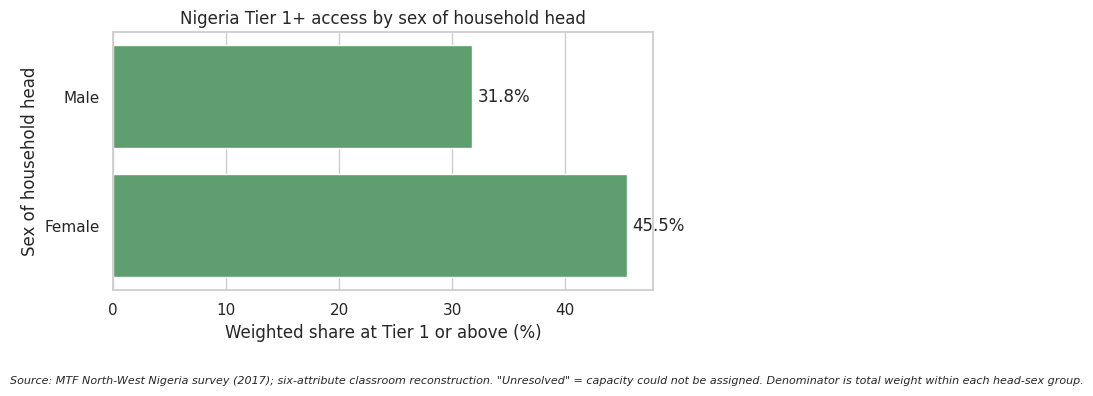

In [ ]:
# Weighted Tier 1+ access split by sex of household head.
sex_tier_one_plus = sex_distribution[tier_one_plus].sum(axis=1).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=sex_tier_one_plus.values,
    y=sex_tier_one_plus.index,
    ax=ax,
    color=sns.color_palette('deep')[2],
    order=sex_tier_one_plus.index.tolist(),
    orient='h'
)

ax.set_xlabel('Weighted share at Tier 1 or above (%)')
ax.set_ylabel('Sex of household head')
ax.set_title('Nigeria Tier 1+ access by sex of household head')
for index, value in enumerate(sex_tier_one_plus):
    ax.text(value + 0.5, index, f'{value:.1f}%', va='center')

plt.tight_layout(rect=(0, 0.08, 1, 1))
fig.text(0.01, 0.02, SOURCE_NOTE + ' Denominator is total weight within each head-sex group.',
         fontsize=8, style='italic')
plt.show()


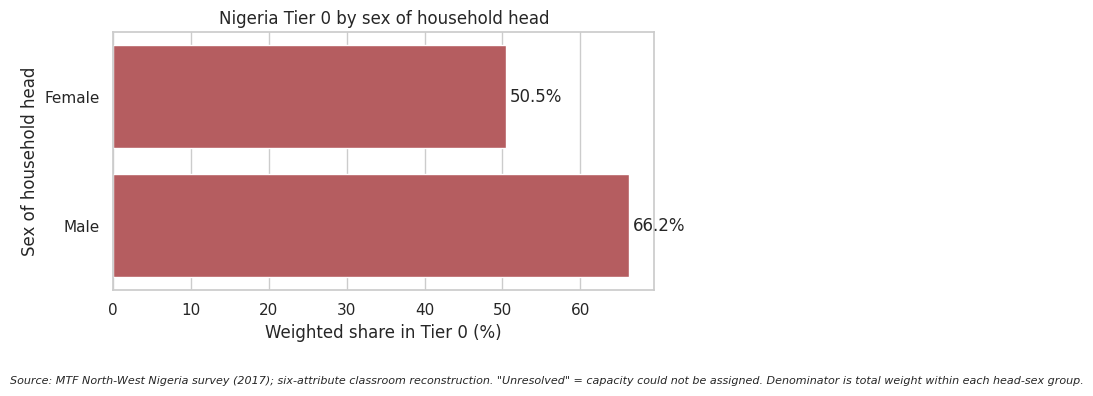

In [ ]:
# Weighted Tier 0 share by sex of household head - the headline gap, split by group.
sex_tier_zero = sex_distribution[0.0].sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=sex_tier_zero.values,
    y=sex_tier_zero.index,
    ax=ax,
    color=sns.color_palette('deep')[3],
    order=sex_tier_zero.index.tolist(),
    orient='h'
)

ax.set_xlabel('Weighted share in Tier 0 (%)')
ax.set_ylabel('Sex of household head')
ax.set_title('Nigeria Tier 0 by sex of household head')
for index, value in enumerate(sex_tier_zero):
    ax.text(value + 0.5, index, f'{value:.1f}%', va='center')

plt.tight_layout(rect=(0, 0.08, 1, 1))
fig.text(0.01, 0.02, SOURCE_NOTE + ' Denominator is total weight within each head-sex group.',
         fontsize=8, style='italic')
plt.show()

## 12a. Access by locality and household head: synthesis

| | |
|---|---|
| **Finding** | Tier 0 is roughly three-quarters of rural weight versus about one-third of urban weight. Female-headed households show a *lower* Tier 0 share than male-headed households in this sample, and a higher Tier 3 share. |
| **Interpretation** | The access gap is overwhelmingly rural. The head-sex pattern is the opposite of the Rwanda finding and is unlikely to be a true "female-headed households do better" effect: female-headed households here skew urban and smaller, so locality and household composition are probably doing the work. Treat it as an association, not a causal claim. |
| **Policy trade-off** | Target the rural extensive-margin gap broadly, or focus narrowly on sub-groups. The rural/urban split is large and robust; the head-sex split is smaller and confounded. |
| **Conditional direction** | Rural households far from grid infrastructure are candidates for off-grid solar; rural households already under existing lines are candidates for subsidised connection. |
| **Evidence needed** | Rural grid proximity and EA infrastructure coverage, household size and income by group, and a like-for-like comparison that holds locality fixed before attributing anything to head sex. |
| **Source data** | 2017 MTF North-West Nigeria survey; six-attribute classroom reconstruction. Sections 10&ndash;12 of this notebook. |


## 13. Tier 0 by state




In [ ]:
def plot_tier_by_state(distribution, tier, color):
    tier_by_state = distribution.loc[distribution.index.notna(), tier].dropna().sort_values()

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(
        x=tier_by_state.values,
        y=tier_by_state.index,
        ax=ax,
        color=color,
        order=tier_by_state.index.tolist(),
        orient='h'
    )

    ax.set_ylabel('State')
    ax.set_xlabel('Weighted percentage of households (within state)')
    ax.set_title(f'Tier {int(tier)} electricity access by state')
    for index, value in enumerate(tier_by_state):
        ax.text(value + 0.3, index, f'{value:.1f}%', va='center')

    plt.tight_layout(rect=(0, 0.07, 1, 1))
    fig.text(0.01, 0.02, SOURCE_NOTE, fontsize=8, style='italic')
    plt.show()


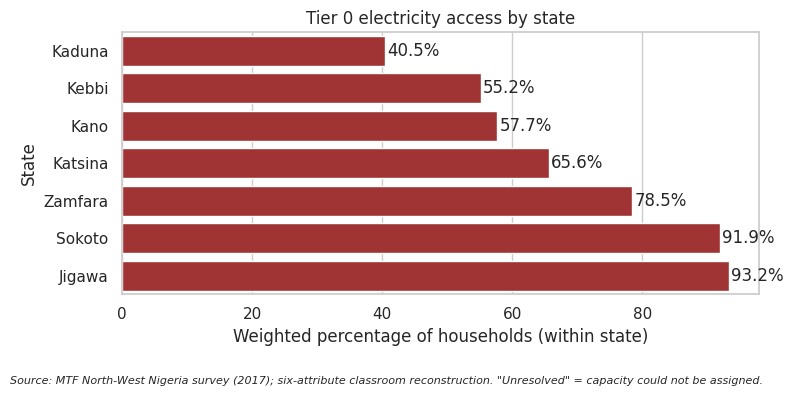

In [ ]:
plot_tier_by_state(region_distribution, tier=0.0, color='firebrick')


## 14. Sensitivity to the dry-cell-battery assumption

Test Sensitivity to Assumptions: change one rule, hold everything else fixed, and see whether the headline &mdash; and the ministry's priorities &mdash; would move.

The load-bearing choice in this reconstruction is how dry-cell-battery households (~54% of the sample) are treated for Capacity:

- **Chosen:** dry-cell battery &rarr; Tier 0 (report Box 1; peak capacity < 3 W).
- **Alt A &mdash; leave unresolved:** the mechanical proxy with no substantive rule; dry-cell capacity stays `NaN`.
- **Alt B &mdash; fill unresolved with Tier 5:** the "no downgrade established = good service" reading, applied to the overall tier.


In [ ]:
# Recompute the weighted overall distribution under three treatments of the
# dry-cell-battery / unresolved decision. Everything else is held fixed.
tier_labels = ['Tier 0', 'Tier 1', 'Tier 2', 'Tier 3', 'Tier 4', 'Tier 5', 'Unresolved']


def weighted_pct_by_tier(tier_series):
    weight = elec['wt']
    total = weight.sum()
    shares = {f'Tier {t}': round(100 * weight[tier_series.eq(t)].sum() / total, 2) for t in range(6)}
    shares['Unresolved'] = round(100 * weight[tier_series.isna()].sum() / total, 2)
    return pd.Series(shares).reindex(tier_labels)


# Mechanical overall tier: the six-attribute minimum WITHOUT the dry-cell -> Tier 0 rule.
mechanical_capacity = elec['tier_capacity'].where(~elec['C182'].eq('Dry-cell battery'))
mechanical_overall = pd.concat(
    [mechanical_capacity, elec[['tier_availability', 'tier_reliability',
                                'tier_quality', 'tier_formality', 'tier_safety']]],
    axis=1,
).min(axis=1, skipna=False)
mechanical_overall = mechanical_overall.mask(elec['C182'].eq('No electricity'), 0)

chosen = elec['tier_overall']                 # dry-cell -> Tier 0; genuine unknowns stay NaN
alt_a = mechanical_overall                    # dry-cell left unresolved
alt_b = mechanical_overall.fillna(5)          # every unresolved household -> Tier 5

sensitivity = pd.DataFrame({
    'chosen: dry-cell -> Tier 0': weighted_pct_by_tier(chosen),
    'alt A: dry-cell unresolved': weighted_pct_by_tier(alt_a),
    'alt B: unresolved -> Tier 5': weighted_pct_by_tier(alt_b),
})
print(sensitivity)
print()
print(
    "Alt A leaves ~60% of survey weight unresolved, so no national tier can be "
    "reported. Alt B pushes that same ~60% into Tier 5, contradicting both the MTF "
    "definition of Tier 0 (dry-cell battery, < 3 W) and the report's 60.7% Tier 0 / "
    "~0% Tier 5. The chosen treatment is the only one consistent with the published "
    "diagnostic, and under all three the ministry-facing conclusion is unchanged: the "
    "dominant gap is households with no Tier 1+ source."
)

            chosen: dry-cell -> Tier 0  alt A: dry-cell unresolved  \
Tier 0                       65.360001                    7.280000   
Tier 1                        2.430000                    2.430000   
Tier 2                       10.640000                   10.640000   
Tier 3                       16.059999                   16.059999   
Tier 4                        2.710000                    2.710000   
Tier 5                        0.690000                    0.690000   
Unresolved                    2.110000                   60.189999   

            alt B: unresolved -> Tier 5  
Tier 0                         7.280000  
Tier 1                         2.430000  
Tier 2                        10.640000  
Tier 3                        16.059999  
Tier 4                         2.710000  
Tier 5                        60.880001  
Unresolved                     0.000000  

Alt A leaves ~60% of survey weight unresolved, so no national tier can be reported. Alt B pushes that 